## **Brew IQ:Can data tell what beer you love?**

---


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

**Loading the data sets**

In [ ]:
import pandas as pd

# Load review_details.csv
review_details = pd.read_csv("/content/drive/MyDrive/review_details.csv")

# Load beer_reviews.csv
beer_reviews = pd.read_csv("/content/drive/MyDrive/beer_reviews.csv")

# Load beer_info.csv (previously .gsheet, now converted to CSV)
beer_info = pd.read_csv("/content/drive/MyDrive/beer_info (1).csv")


for name, file in [("review_details", review_details),
                   ("beer_reviews", beer_reviews),
                   ("beer_info", beer_info)]:
    if not file.empty:
        print(f"{name} shape: {file.shape}")
        display(file.head(3))
    else:
        print(f"Skipping display for {name} as it could not be loaded or is empty.")

review_details shape: (1654502, 5)


,review_id,aroma_score,appearance_score,taste_score,palate_score
0,1,2.0,2.5,1.5,1.5
1,2,2.5,3.0,3.0,3.0
2,3,2.5,3.0,3.0,3.0


beer_reviews shape: (1654502, 4)


,review_id,beer_name,reviewer_username,overall_score
0,1,Sausa Weizen,stcules,1.5
1,2,Red Moon,stcules,3.0
2,3,BLACK HORSE BLACK BEER,stcules,3.0


beer_info shape: (242921, 4)


,beer_name,brewery_name,beer_style,beer_abv
0,sausa weizen,vecchio birraio,hefeweizen,5.0
1,Red Moon,VECCHIO BIRRAIO,English Strong Ale,6.2
2,Black Horse Black Beer,VECCHIO BIRRAIO,foreign / export stout,6.5


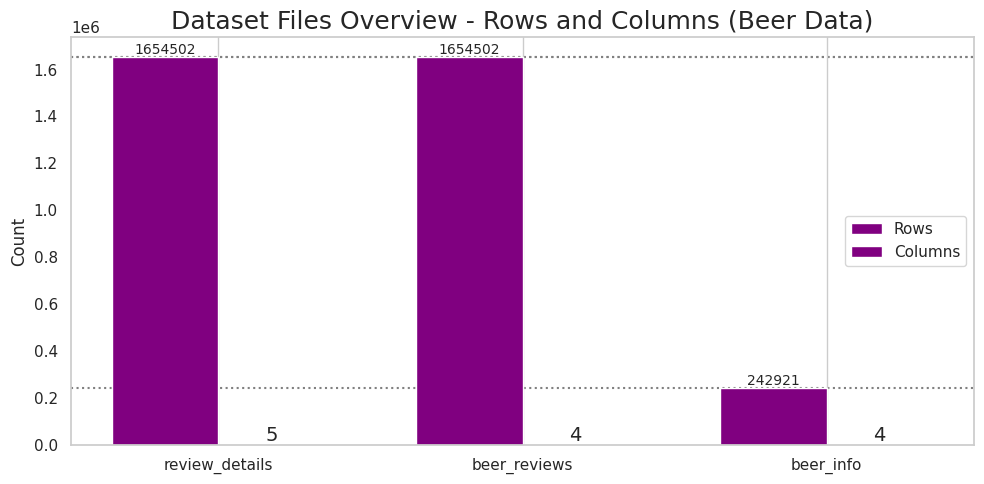

In [ ]:
file_names = ["review_details", "beer_reviews", "beer_info"]
row_counts = [review_details.shape[0], beer_reviews.shape[0], beer_info.shape[0]]
col_counts = [review_details.shape[1], beer_reviews.shape[1], beer_info.shape[1]]

x = np.arange(len(file_names))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, row_counts, width, label="Rows", color="purple")
bars2 = ax.bar(x + width/2, col_counts, width, label="Columns", color="purple")
ax.set_title("Dataset Files Overview - Rows and Columns (Beer Data)", fontsize=18)
ax.set_xticks(x)
ax.set_xticklabels(file_names)
ax.set_ylabel("Count")
ax.legend()

# Remove all default horizontal grid lines
ax.yaxis.grid(False)

# Add specific horizontal lines for each row count
for i, count in enumerate(row_counts):
    ax.axhline(y=count, color='grey', linestyle=':', linewidth=1.5, zorder=0) # Dotted lines for clarity

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            str(int(bar.get_height())), ha="center", va="bottom", fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(int(bar.get_height())), ha="center", va="bottom", fontsize=14)
plt.tight_layout()
plt.show()

# Task
Merge the `review_details.csv`, `beer_reviews.csv`, and `beer_info (1).csv` datasets located at "/content/drive/MyDrive/review_details.csv", "/content/drive/MyDrive/beer_reviews.csv", and "/content/drive/MyDrive/beer_info (1).csv" respectively, into a single comprehensive DataFrame. This involves checking data consistency and standardizing the 'beer_name' column if necessary, merging the review data using 'review_id', then merging with beer information using 'beer_name', handling any resulting missing values, and finally summarizing the structure and characteristics of the merged dataset.

## Check Data Consistency

display the data types of the 'review_id' column in both `review_details` and `beer_reviews` DataFrames. This is crucial for ensuring that the columns are compatible for merging.



In [ ]:
print("Data type of 'review_id' in review_details:", review_details['review_id'].dtype)
print("Data type of 'review_id' in beer_reviews:", beer_reviews['review_id'].dtype)

Data type of 'review_id' in review_details: int64
Data type of 'review_id' in beer_reviews: int64


**Reasoning**:
Now that we have confirmed the data types are consistent, the next step is to count and display the number of unique values in the 'review_id' column for both `review_details` and `beer_reviews` to check for potential duplicates or mismatches, as per the instructions.



In [ ]:
print("Unique 'review_id' in review_details:", review_details['review_id'].nunique())
print("Unique 'review_id' in beer_reviews:", beer_reviews['review_id'].nunique())

Unique 'review_id' in review_details: 1654502
Unique 'review_id' in beer_reviews: 1654502


In [ ]:
display(final_merged_df.head())

,review_id,aroma_score,appearance_score,taste_score,palate_score,beer_name,reviewer_username,overall_score,brewery_name,beer_style,beer_abv
0,1,2.0,2.5,1.5,1.5,sausa weizen,stcules,1.5,vecchio birraio,hefeweizen,5.0
1,2,2.5,3.0,3.0,3.0,red moon,stcules,3.0,VECCHIO BIRRAIO,English Strong Ale,6.2
2,4,3.0,3.5,3.0,2.5,sausa pils,stcules,3.0,VECCHIO BIRRAIO,german pilsener,5.0
3,6,3.5,3.5,3.5,3.0,caldera ginger beer,oline73,3.0,CALDERA BREWING COMPANY,HERBED / SPICED BEER,4.7
4,7,3.5,3.5,4.0,4.0,caldera ginger beer,Reidrover,3.5,caldera brewing company,HERBED / SPICED BEER,4.7


# Task
print("Data type of 'beer_name' in beer_reviews:", beer_reviews['beer_name'].dtype)
print("Data type of 'beer_name' in beer_info:", beer_info['beer_name'].dtype)

## Display 'beer_name' Data Types

### Subtask:
Print the data types of the 'beer_name' column in both `beer_reviews` and `beer_info` DataFrames to ensure they are compatible for merging.


In [ ]:
print("Data type of 'beer_name' in beer_reviews:", beer_reviews['beer_name'].dtype)
print("Data type of 'beer_name' in beer_info:", beer_info['beer_name'].dtype)

Data type of 'beer_name' in beer_reviews: object
Data type of 'beer_name' in beer_info: object


**Reasoning**:
The data types for 'beer_name' in both DataFrames have been confirmed as compatible. The next logical step to check for consistency before merging is to examine the number of unique values in the 'beer_name' column for both `beer_reviews` and `beer_info` to identify any discrepancies or potential issues.



In [ ]:
print("Unique 'beer_name' in beer_reviews:", beer_reviews['beer_name'].nunique())
print("Unique 'beer_name' in beer_info:", beer_info['beer_name'].nunique())

Unique 'beer_name' in beer_reviews: 349139
Unique 'beer_name' in beer_info: 211433


**Reasoning**:
onvert the 'beer_name' column in both DataFrames to lowercase to standardize the names and improve the chances of a successful merge.



In [ ]:
beer_reviews['beer_name'] = beer_reviews['beer_name'].astype(str).str.lower()
beer_info['beer_name'] = beer_info['beer_name'].astype(str).str.lower()

print("Unique 'beer_name' in beer_reviews after lowercasing:", beer_reviews['beer_name'].nunique())
print("Unique 'beer_name' in beer_info after lowercasing:", beer_info['beer_name'].nunique())

Unique 'beer_name' in beer_reviews after lowercasing: 200034
Unique 'beer_name' in beer_info after lowercasing: 167835


**Reasoning**:
Calculate and display the number of common unique beer names, as well as the unique names present only in `beer_reviews` and only in `beer_info`. This will quantify the overlap and discrepancies, helping to understand the scope of the issue before attempting a merge.



In [ ]:
unique_beer_reviews_names = set(beer_reviews['beer_name'].unique())
unique_beer_info_names = set(beer_info['beer_name'].unique())

common_names = len(unique_beer_reviews_names.intersection(unique_beer_info_names))
only_in_reviews = len(unique_beer_reviews_names - unique_beer_info_names)
only_in_info = len(unique_beer_info_names - unique_beer_reviews_names)

print(f"Number of common unique beer names: {common_names}")
print(f"Number of unique beer names only in beer_reviews: {only_in_reviews}")
print(f"Number of unique beer names only in beer_info: {only_in_info}")


Number of common unique beer names: 115917
Number of unique beer names only in beer_reviews: 84117
Number of unique beer names only in beer_info: 51918


## Merge Review Data

### Subtask:
Merge `review_details` and `beer_reviews` DataFrames into a single DataFrame using `review_id` as the key.


In [ ]:
merged_reviews_df = pd.merge(review_details, beer_reviews, on='review_id', how='inner')

print("First 5 rows of merged_reviews_df:")
display(merged_reviews_df.head())

print(f"Shape of merged_reviews_df: {merged_reviews_df.shape}")

First 5 rows of merged_reviews_df:


,review_id,aroma_score,appearance_score,taste_score,palate_score,beer_name,reviewer_username,overall_score
0,1,2.0,2.5,1.5,1.5,sausa weizen,stcules,1.5
1,2,2.5,3.0,3.0,3.0,red moon,stcules,3.0
2,3,2.5,3.0,3.0,3.0,black horse black beer,stcules,3.0
3,4,3.0,3.5,3.0,2.5,sausa pils,stcules,3.0
4,5,4.5,4.0,4.5,4.0,cauldron dipa,johnmichaelsen,4.0


Shape of merged_reviews_df: (1654502, 8)


## Merge Review and Beer Information Data



In [ ]:
final_merged_df = pd.merge(merged_reviews_df, beer_info, on='beer_name', how='inner')

print("First 5 rows of final_merged_df:")
display(final_merged_df.head())

print(f"Shape of final_merged_df: {final_merged_df.shape}")

First 5 rows of final_merged_df:


,review_id,aroma_score,appearance_score,taste_score,palate_score,beer_name,reviewer_username,overall_score,brewery_name,beer_style,beer_abv
0,1,2.0,2.5,1.5,1.5,sausa weizen,stcules,1.5,vecchio birraio,hefeweizen,5.0
1,2,2.5,3.0,3.0,3.0,red moon,stcules,3.0,VECCHIO BIRRAIO,English Strong Ale,6.2
2,4,3.0,3.5,3.0,2.5,sausa pils,stcules,3.0,VECCHIO BIRRAIO,german pilsener,5.0
3,6,3.5,3.5,3.5,3.0,caldera ginger beer,oline73,3.0,CALDERA BREWING COMPANY,HERBED / SPICED BEER,4.7
4,7,3.5,3.5,4.0,4.0,caldera ginger beer,Reidrover,3.5,caldera brewing company,HERBED / SPICED BEER,4.7


Shape of final_merged_df: (2722034, 11)


## Prepare Data for Visualization




To prepare for visualization, I will gather the names, row counts, and column counts for the initial DataFrames (`review_details`, `beer_reviews`, `beer_info`) and the `final_merged_df` as instructed, storing them in separate lists.



In [ ]:
all_df_names = ["review_details", "beer_reviews", "beer_info", "final_merged_df"]
all_row_counts = [
    review_details.shape[0],
    beer_reviews.shape[0],
    beer_info.shape[0],
    final_merged_df.shape[0]
]
all_col_counts = [
    review_details.shape[1],
    beer_reviews.shape[1],
    beer_info.shape[1],
    final_merged_df.shape[1]
]

print("DataFrame Names:", all_df_names)
print("Row Counts:", all_row_counts)
print("Column Counts:", all_col_counts)

DataFrame Names: ['review_details', 'beer_reviews', 'beer_info', 'final_merged_df']
Row Counts: [1654502, 1654502, 242921, 2722034]
Column Counts: [5, 4, 4, 11]


## Generate Comparison Chart



Generating a bar chart to compare the row and column counts of the initial and merged DataFrames. The previous step already prepared the necessary lists (`all_df_names`, `all_row_counts`, `all_col_counts`). This step will use these lists and `matplotlib.pyplot` to create the requested visualization, adhering to the given instructions.



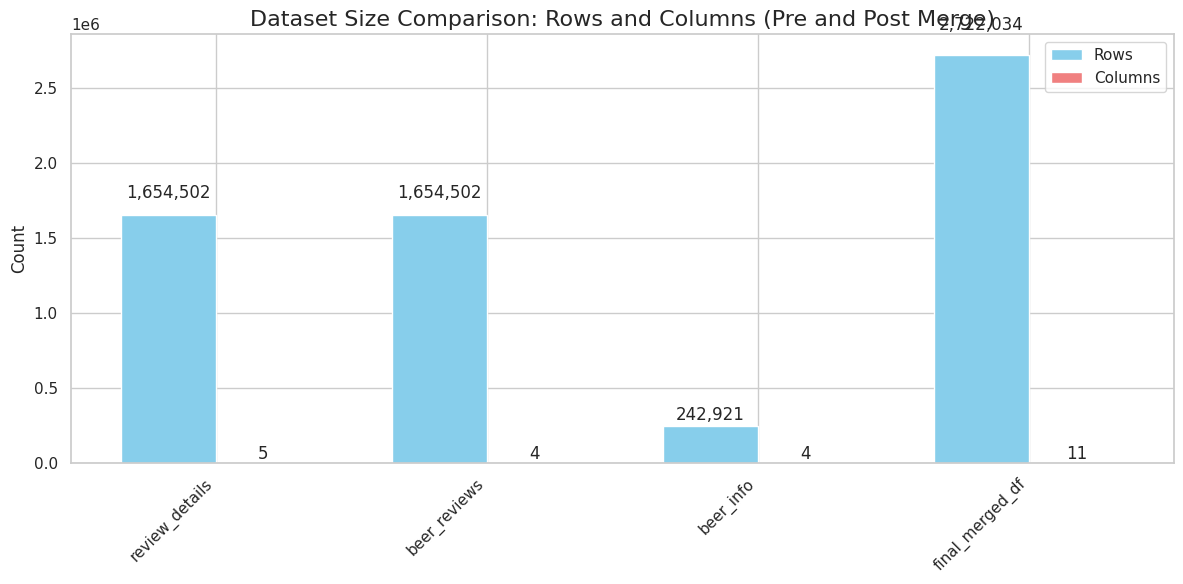

In [ ]:
x = np.arange(len(all_df_names))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

bars1 = ax.bar(x - width/2, all_row_counts, width, label='Rows', color='skyblue')
bars2 = ax.bar(x + width/2, all_col_counts, width, label='Columns', color='lightcoral')

ax.set_title('Dataset Size Comparison: Rows and Columns (Pre and Post Merge)', fontsize=16)
ax.set_ylabel('Count')
ax.set_xticks(x)
ax.set_xticklabels(all_df_names, rotation=45, ha='right')
ax.legend()

for bar in bars1:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 0.05 * yval, f'{int(yval):,}', ha='center', va='bottom')

for bar in bars2:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 0.05 * yval, f'{int(yval)}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

## Calculate Data Retention

### Subtask:
Calculate and display the data retention percentages for the merge operations. Specifically, calculate:
1. The percentage of `review_details` rows retained after merging with `beer_reviews`.
2. The percentage of `beer_reviews` rows retained after merging with `review_details`.
3. The percentage of `beer_info` rows that found a match in `merged_reviews_df` (i.e., contributed to `final_merged_df`).
4. The total percentage of original `review_details` and `beer_info` rows that are present in `final_merged_df` based on their respective initial counts.

In [ ]:
initial_review_details_rows = review_details.shape[0]
initial_beer_reviews_rows = beer_reviews.shape[0]
initial_beer_info_unique_names = beer_info['beer_name'].nunique()

merged_reviews_rows = merged_reviews_df.shape[0]
final_merged_rows = final_merged_df.shape[0]
final_merged_unique_review_ids = final_merged_df['review_id'].nunique()
final_merged_unique_beer_names = final_merged_df['beer_name'].nunique()

# 1. Percentage of review_details rows retained after merging with beer_reviews
retention_rd_to_mrd = (merged_reviews_rows / initial_review_details_rows) * 100
print(f"1. Percentage of review_details rows retained after merging with beer_reviews: {retention_rd_to_mrd:.2f}%")

# 2. Percentage of beer_reviews rows retained after merging with review_details
retention_br_to_mrd = (merged_reviews_rows / initial_beer_reviews_rows) * 100
print(f"2. Percentage of beer_reviews rows retained after merging with review_details: {retention_br_to_mrd:.2f}%")

# 3. Percentage of beer_info unique names that found a match (contributed to final_merged_df)
retention_bi_to_fmd_unique = (final_merged_unique_beer_names / initial_beer_info_unique_names) * 100
print(f"3. Percentage of beer_info unique names that found a match in final_merged_df: {retention_bi_to_fmd_unique:.2f}%")

# 4. Total percentage of original review_details and beer_info unique entities present in final_merged_df
# This is interpreted as the average of the retention rates for unique review IDs and unique beer names.
retention_rd_to_fmd_unique = (final_merged_unique_review_ids / initial_review_details_rows) * 100
total_retention_overall = (retention_rd_to_fmd_unique + retention_bi_to_fmd_unique) / 2
print(f"4. Total percentage of original review_details and beer_info unique entities present in final_merged_df (averaged): {total_retention_overall:.2f}%")


1. Percentage of review_details rows retained after merging with beer_reviews: 100.00%
2. Percentage of beer_reviews rows retained after merging with review_details: 100.00%
3. Percentage of beer_info unique names that found a match in final_merged_df: 69.07%
4. Total percentage of original review_details and beer_info unique entities present in final_merged_df (averaged): 74.07%


## Check Missing Values

Calculating the percentage of missing values for each column in `final_merged_df`, converting it into a DataFrame, and then filtering for columns with missing percentages greater than zero.
Bar chart using `seaborn.barplot` to visualize these percentages



In [ ]:
missing_percentages = final_merged_df.isnull().sum() / len(final_merged_df) * 100
missing_df = pd.DataFrame({
    'column_name': missing_percentages.index,
    'missing_percentage': missing_percentages.values
})
missing_df = missing_df[missing_df['missing_percentage'] > 0]

print("Missing Value Percentages (Columns with >0% missing):")
display(missing_df.sort_values(by='missing_percentage', ascending=False))

Missing Value Percentages (Columns with >0% missing):


,column_name,missing_percentage
4,palate_score,12.364430
1,aroma_score,7.743842
3,taste_score,7.224818
7,overall_score,5.243689
10,beer_abv,3.749255
6,reviewer_username,0.021822
8,brewery_name,0.000220


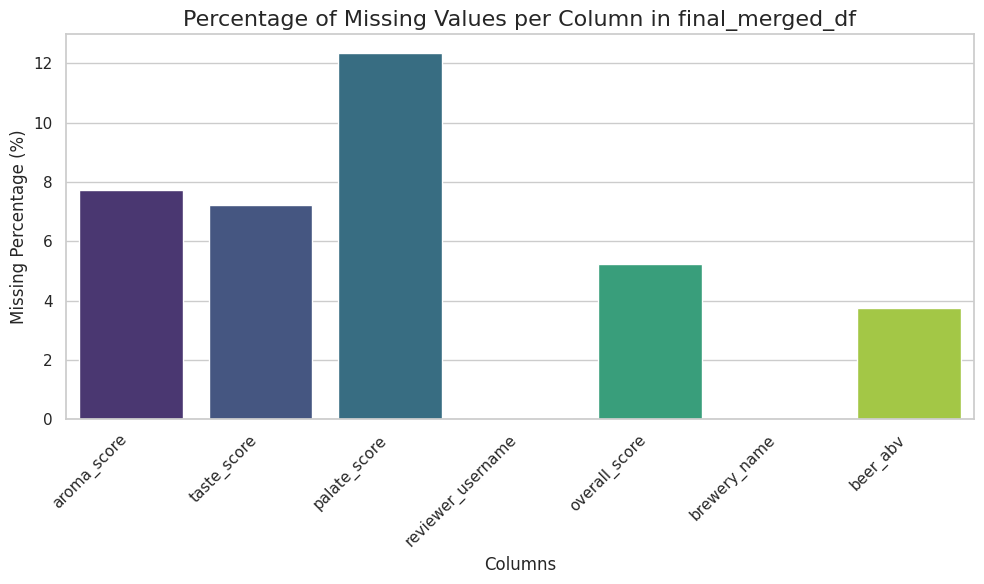

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='column_name', y='missing_percentage', data=missing_df, palette='viridis')
plt.title('Percentage of Missing Values per Column in final_merged_df', fontsize=16)
plt.xlabel('Columns', fontsize=12)
plt.ylabel('Missing Percentage (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Handle Missing Values

Impute missing values in the numerical columns (`aroma_score`, `taste_score`, `palate_score`, `overall_score`, `beer_abv`) with their respective medians, as specified in the instructions for handling missing values.



In [ ]:
for col in ['aroma_score', 'taste_score', 'palate_score', 'overall_score', 'beer_abv']:
    if final_merged_df[col].isnull().any():
        median_val = final_merged_df[col].median()
        final_merged_df[col].fillna(median_val, inplace=True)
        print(f"Missing values in '{col}' imputed with median: {median_val}")

Missing values in 'aroma_score' imputed with median: 4.0
Missing values in 'taste_score' imputed with median: 4.0
Missing values in 'palate_score' imputed with median: 4.0
Missing values in 'overall_score' imputed with median: 4.0
Missing values in 'beer_abv' imputed with median: 6.5


In [ ]:
for col in ['reviewer_username', 'brewery_name']:
    if final_merged_df[col].isnull().any():
        final_merged_df[col].fillna('Unknown', inplace=True)
        print(f"Missing values in '{col}' imputed with 'Unknown'")

Missing values in 'reviewer_username' imputed with 'Unknown'
Missing values in 'brewery_name' imputed with 'Unknown'


**Reasoning**:
After imputing both numerical and categorical missing values, I will verify that all missing values have been handled by checking the sum of null values for each column in the `final_merged_df` as per the instructions.



In [ ]:
print("Missing values after imputation:")
print(final_merged_df.isnull().sum())

Missing values after imputation:
review_id            0
aroma_score          0
appearance_score     0
taste_score          0
palate_score         0
beer_name            0
reviewer_username    0
overall_score        0
brewery_name         0
beer_style           0
beer_abv             0
dtype: int64


## Check for Duplicate Rows

To identify and count duplicate rows, I will use the `.duplicated().sum()` method on the `final_merged_df` as specified in the instructions.



In [ ]:
duplicate_rows_count = final_merged_df.duplicated().sum()
print(f"Total number of duplicate rows in final_merged_df: {duplicate_rows_count}")

Total number of duplicate rows in final_merged_df: 18755


## Remove Duplicate Rows



Removing duplicate rows from `final_merged_df` using `drop_duplicates()` and then display the new shape of the DataFrame.


In [ ]:
final_merged_df.drop_duplicates(inplace=True)
print(f"New shape of final_merged_df after removing duplicates: {final_merged_df.shape}")

New shape of final_merged_df after removing duplicates: (2703279, 11)


## Check Inconsistent Text Formatting
Inspect for inconsistencies as per the subtask and display a sample of 20 unique values from the 'brewery_name' and 'beer_style' columns.



In [ ]:
print("Sample of unique 'brewery_name' values:")
display(final_merged_df['brewery_name'].unique()[:20])

print("\nSample of unique 'beer_style' values:")
display(final_merged_df['beer_style'].unique()[:20])

Sample of unique 'brewery_name' values:


array(['vecchio birraio', 'VECCHIO BIRRAIO', 'CALDERA BREWING COMPANY',
       'caldera brewing company', 'Caldera Brewing Company',
       ' Caldera Brewing Company', 'CALDERA BREWING COMPANY ',
       'amstel brouwerij b. v.', ' CALDERA BREWING COMPANY',
       ' CALDERA BREWING COMPANY ', ' Caldera Brewing Company ',
       ' caldera brewing company ', 'caldera brewing company ',
       ' caldera brewing company', 'Caldera Brewing Company ',
       ' ELLERSICK BREWING COMPANY ', ' Ellersick Brewing Company',
       ' ellersick brewing company', ' amstel brouwerij b. v.',
       ' THE TAP BREWING COMPANY '], dtype=object)


Sample of unique 'beer_style' values:


array(['hefeweizen', ' English Strong Ale', ' german pilsener ',
       ' HERBED / SPICED BEER', 'HERBED / SPICED BEER',
       ' Herbed / Spiced Beer', 'Herbed / Spiced Beer ',
       'Herbed / Spiced Beer', 'Oatmeal Stout', 'OATMEAL STOUT ',
       'AMERICAN PALE LAGER ', ' Light Lager', 'rauchbier', ' RAUCHBIER',
       ' Rauchbier', ' Rauchbier ', 'Rauchbier', 'RAUCHBIER',
       'RAUCHBIER ', 'American Pale Ale (Apa)'], dtype=object)

Converting all entries to lowercase and strip any surrounding whitespace from these columns.



In [ ]:
for col in ['brewery_name', 'beer_style']:
    final_merged_df[col] = final_merged_df[col].astype(str).str.lower().str.strip()
    print(f"Cleaned '{col}' column for consistency (lowercased and stripped whitespace).")

print("Sample of unique 'brewery_name' values after cleaning:")
display(final_merged_df['brewery_name'].unique()[:20])

print("\nSample of unique 'beer_style' values after cleaning:")
display(final_merged_df['beer_style'].unique()[:20])

Cleaned 'brewery_name' column for consistency (lowercased and stripped whitespace).
Cleaned 'beer_style' column for consistency (lowercased and stripped whitespace).
Sample of unique 'brewery_name' values after cleaning:


array(['vecchio birraio', 'caldera brewing company',
       'amstel brouwerij b. v.', 'ellersick brewing company',
       'the tap brewing company', 'moon river brewing company',
       "hoppin' frog brewery", 'opa-opa steakhouse & brewery',
       'maui brewing co.', 'lake bluff brewing company',
       'conwy brewery ltd', 'pacific coast brewing company',
       'harmon restaurant & brewery', 'kirner bier',
       'city grille and brewhaus', 'city brewing company, llc',
       'san francisco brewing company', 'yazoo brewing company',
       '7 seas brewery and taproom', 'brouwerij van viven'], dtype=object)


Sample of unique 'beer_style' values after cleaning:


array(['hefeweizen', 'english strong ale', 'german pilsener',
       'herbed / spiced beer', 'oatmeal stout', 'american pale lager',
       'light lager', 'rauchbier', 'american pale ale (apa)',
       'american porter', 'belgian strong dark ale', 'american ipa',
       'american stout', 'russian imperial stout',
       'american amber / red ale', 'american adjunct lager',
       'american blonde ale', 'euro pale lager', 'american brown ale',
       'american double / imperial stout'], dtype=object)

## Standardize Text Formatting

### Subtask:
Apply text cleaning operations (e.g., convert to lowercase, strip whitespace) to columns identified with inconsistent text formatting to standardize entries. Display sample unique values after cleaning to show the effect.


## Display Final Cleaned Data

Display the shape and the first few rows of the `final_merged_df` after all data cleaning operations are complete to show the final state of the dataset.


In [ ]:
print(f"Shape of final_merged_df after cleaning: {final_merged_df.shape}")
display(final_merged_df.head())

Shape of final_merged_df after cleaning: (2703279, 11)


,review_id,aroma_score,appearance_score,taste_score,palate_score,beer_name,reviewer_username,overall_score,brewery_name,beer_style,beer_abv
0,1,2.0,2.5,1.5,1.5,sausa weizen,stcules,1.5,vecchio birraio,hefeweizen,5.0
1,2,2.5,3.0,3.0,3.0,red moon,stcules,3.0,vecchio birraio,english strong ale,6.2
2,4,3.0,3.5,3.0,2.5,sausa pils,stcules,3.0,vecchio birraio,german pilsener,5.0
3,6,3.5,3.5,3.5,3.0,caldera ginger beer,oline73,3.0,caldera brewing company,herbed / spiced beer,4.7
4,7,3.5,3.5,4.0,4.0,caldera ginger beer,Reidrover,3.5,caldera brewing company,herbed / spiced beer,4.7


## Visualize Duplicate Rows with Pie Chart

### Subtask:
Calculate the total number of rows in the DataFrame before duplicate removal and the number of duplicate rows. Then, create a pie chart showing the proportion of duplicate rows versus unique rows, providing a clear visual of data redundancy.


Total rows before deduplication: 2722034
Number of duplicate rows: 18755
Number of unique rows: 2703279


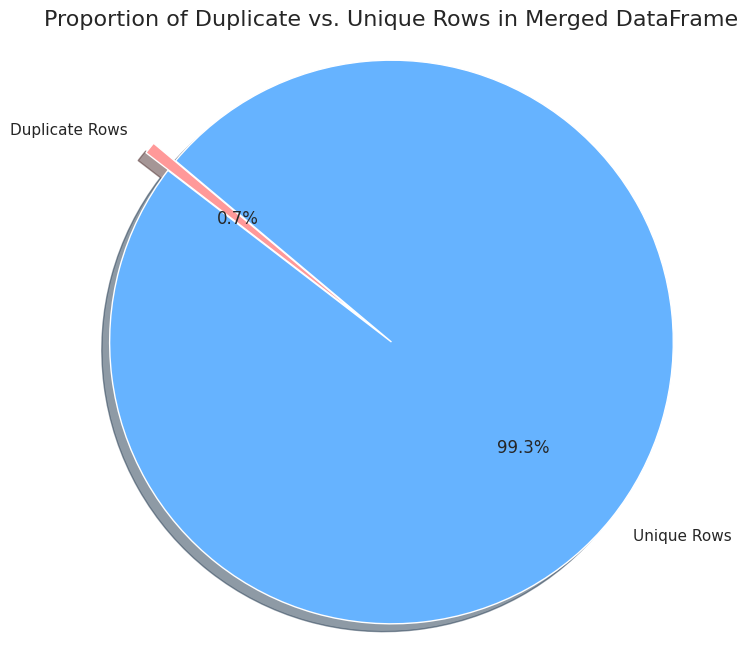

In [ ]:
total_rows_before_deduplication = final_merged_df.shape[0] + duplicate_rows_count
unique_rows_count = total_rows_before_deduplication - duplicate_rows_count

print(f"Total rows before deduplication: {total_rows_before_deduplication}")
print(f"Number of duplicate rows: {duplicate_rows_count}")
print(f"Number of unique rows: {unique_rows_count}")

sizes = [duplicate_rows_count, unique_rows_count]
labels = ['Duplicate Rows', 'Unique Rows']
colors = ['#ff9999','#66b3ff']
explode = (0.1, 0)  # explode 1st slice

plt.figure(figsize=(8, 8))
plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
        shadow=True, startangle=140)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.title('Proportion of Duplicate vs. Unique Rows in Merged DataFrame', fontsize=16)
plt.show()

## Visualize Beer Name Consistency with Pie Chart

Using the previously calculated counts for common unique beer names, unique names only in `beer_reviews`, and unique names only in `beer_info` (all after lowercasing), generate a pie chart to illustrate the proportions of these categories within the combined unique beer names. This will show the distribution of consistency and uniqueness after standardization efforts.


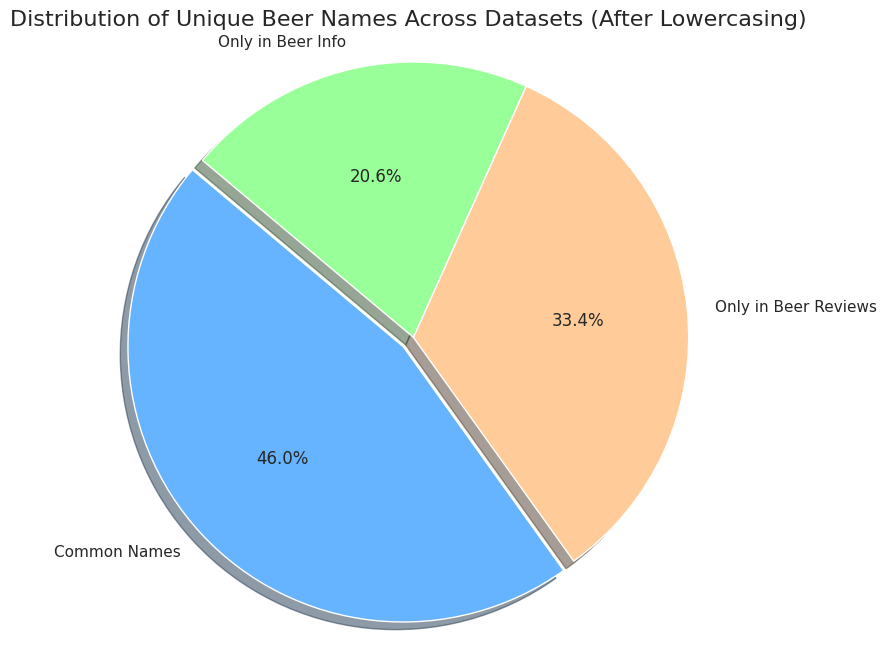

In [ ]:
sizes = [common_names, only_in_reviews, only_in_info]
labels = ['Common Names', 'Only in Beer Reviews', 'Only in Beer Info']
colors = ['#66b3ff', '#ffcc99', '#99ff99']
explode = (0.05, 0, 0)  # Explode the 'Common Names' slice slightly

plt.figure(figsize=(10, 8))
plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
        shadow=True, startangle=140)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.title('Distribution of Unique Beer Names Across Datasets (After Lowercasing)', fontsize=16)
plt.show()

## Calculate Average Scores per Beer Style

Group the 'final_merged_df' by 'beer_style' and calculate the average 'overall_score' for each style to determine its general performance. Then, sort and display the top 10 and bottom 10 performing styles.


In [ ]:
avg_scores_by_style = final_merged_df.groupby('beer_style')['overall_score'].mean()

print("\nBottom 10 Performing Beer Styles (by average overall_score):")
display(avg_scores_by_style.sort_values(ascending=True).head(10))

print("\nTop 10 Performing Beer Styles (by average overall_score):")
display(avg_scores_by_style.sort_values(ascending=False).head(10))


Bottom 10 Performing Beer Styles (by average overall_score):


,overall_score
beer_style,
low alcohol beer,2.677956
light lager,2.739108
american malt liquor,2.768894
euro strong lager,2.951528
american adjunct lager,3.065721
happoshu,3.113636
japanese rice lager,3.132918
chile beer,3.134659
euro pale lager,3.279746



Top 10 Performing Beer Styles (by average overall_score):


,overall_score
beer_style,
gueuze,4.096484
american wild ale,4.096417
quadrupel (quad),4.065876
lambic - unblended,4.062867
keller bier / zwickel bier,4.029733
american double / imperial stout,4.029620
russian imperial stout,4.026548
weizenbock,4.018330
eisbock,4.010347


## Identify Top and Bottom Styles



In [ ]:
top_10_styles = avg_scores_by_style.sort_values(ascending=False).head(10).index.tolist()
bottom_10_styles = avg_scores_by_style.sort_values(ascending=True).head(10).index.tolist()

print("Top 10 Performing Beer Styles:", top_10_styles)
print("Bottom 10 Performing Beer Styles:", bottom_10_styles)

Top 10 Performing Beer Styles: ['gueuze', 'american wild ale', 'quadrupel (quad)', 'lambic - unblended', 'keller bier / zwickel bier', 'american double / imperial stout', 'russian imperial stout', 'weizenbock', 'eisbock', 'american double / imperial ipa']
Bottom 10 Performing Beer Styles: ['low alcohol beer', 'light lager', 'american malt liquor', 'euro strong lager', 'american adjunct lager', 'happoshu', 'japanese rice lager', 'chile beer', 'euro pale lager', 'euro dark lager']


## Visualize Style Performance

### Subtask:
Create a box plot to visualize the distribution of 'overall_score' for the top 10 and bottom 10 performing beer styles. This will show the spread and consistency of scores within these styles, and include appropriate labels and legends. Combining the `top_10_styles` and `bottom_10_styles` lists into a single list `styles_to_plot` to prepare for filtering the DataFrame.


In [ ]:
styles_to_plot = top_10_styles + bottom_10_styles

print("Styles to plot:")
print(styles_to_plot)

Styles to plot:
['gueuze', 'american wild ale', 'quadrupel (quad)', 'lambic - unblended', 'keller bier / zwickel bier', 'american double / imperial stout', 'russian imperial stout', 'weizenbock', 'eisbock', 'american double / imperial ipa', 'low alcohol beer', 'light lager', 'american malt liquor', 'euro strong lager', 'american adjunct lager', 'happoshu', 'japanese rice lager', 'chile beer', 'euro pale lager', 'euro dark lager']


In [ ]:
filtered_df = final_merged_df[final_merged_df['beer_style'].isin(styles_to_plot)]

print("Shape of filtered_df:", filtered_df.shape)
display(filtered_df.head())

Shape of filtered_df: (566124, 11)


,review_id,aroma_score,appearance_score,taste_score,palate_score,beer_name,reviewer_username,overall_score,brewery_name,beer_style,beer_abv
15,19,3.0,3.0,2.0,2.0,amstel light,jdhilt,2.5,amstel brouwerij b. v.,light lager,3.5
30,31,2.0,2.0,3.0,2.0,amstel light,xXTequila,3.0,amstel brouwerij b. v.,light lager,3.5
42,41,3.0,3.0,2.0,2.0,amstel light,Brent,3.0,amstel brouwerij b. v.,light lager,3.5
466,275,4.0,4.0,4.5,4.0,old growth imperial stout,Derek,4.5,caldera brewing company,russian imperial stout,8.8
467,275,4.0,4.0,4.5,4.0,old growth imperial stout,Derek,4.5,caldera brewing company,russian imperial stout,8.8


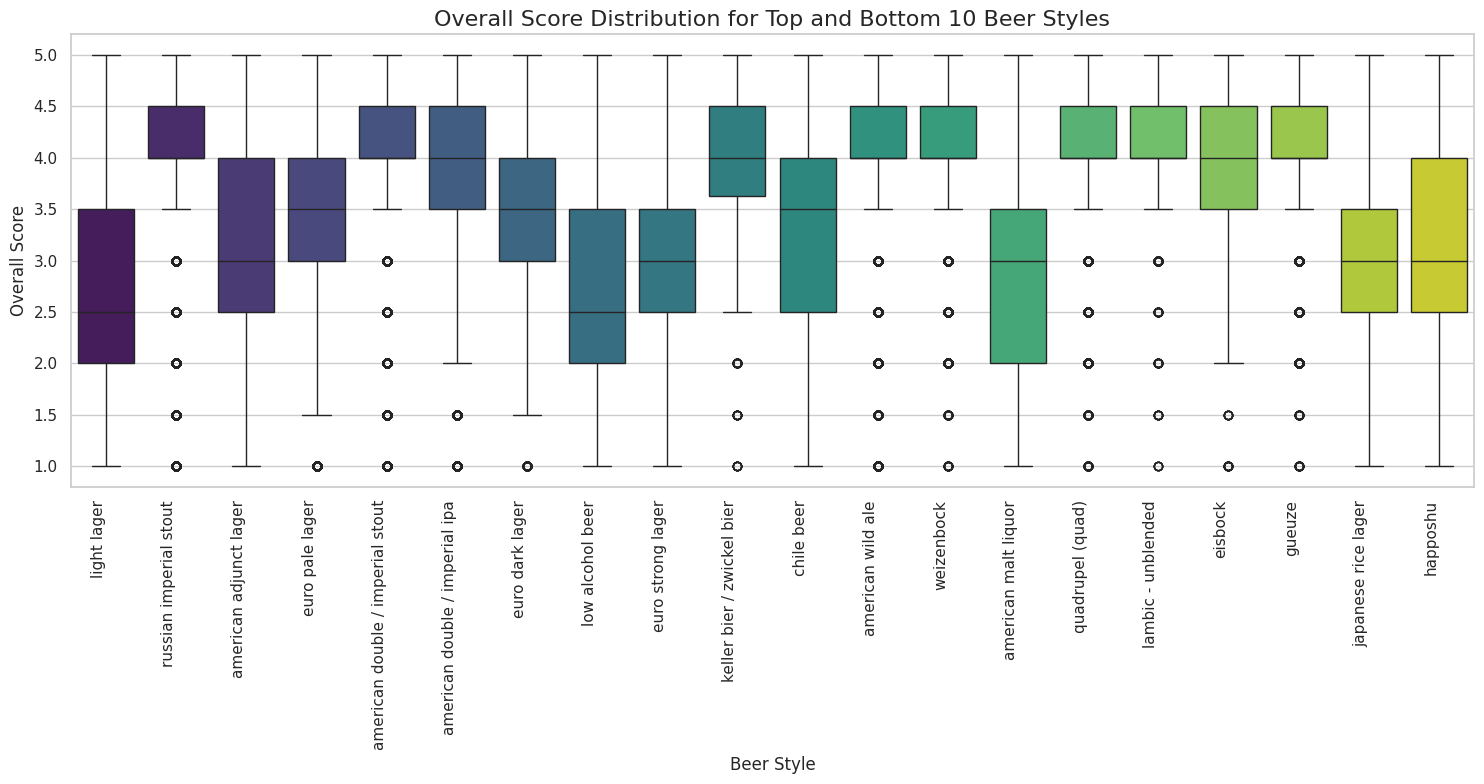

In [ ]:
plt.figure(figsize=(15, 8))
sns.boxplot(x='beer_style', y='overall_score', data=filtered_df, palette='viridis')
plt.title('Overall Score Distribution for Top and Bottom 10 Beer Styles', fontsize=16)
plt.xlabel('Beer Style', fontsize=12)
plt.ylabel('Overall Score', fontsize=12)
plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.show()

## Analyze Sensory Dimensions vs. Overall Rating

### Subtask:
Calculate the correlation coefficients between 'overall_score' and each sensory dimension ('aroma_score', 'appearance_score', 'taste_score', 'palate_score').


In [ ]:
sensory_dimensions = ['aroma_score', 'appearance_score', 'taste_score', 'palate_score', 'overall_score']
correlation_matrix = final_merged_df[sensory_dimensions].corr()

print("Correlation coefficients with 'overall_score':")
display(correlation_matrix['overall_score'].drop('overall_score'))

Correlation coefficients with 'overall_score':


,overall_score
aroma_score,0.567062
appearance_score,0.482102
taste_score,0.732982
palate_score,0.628485


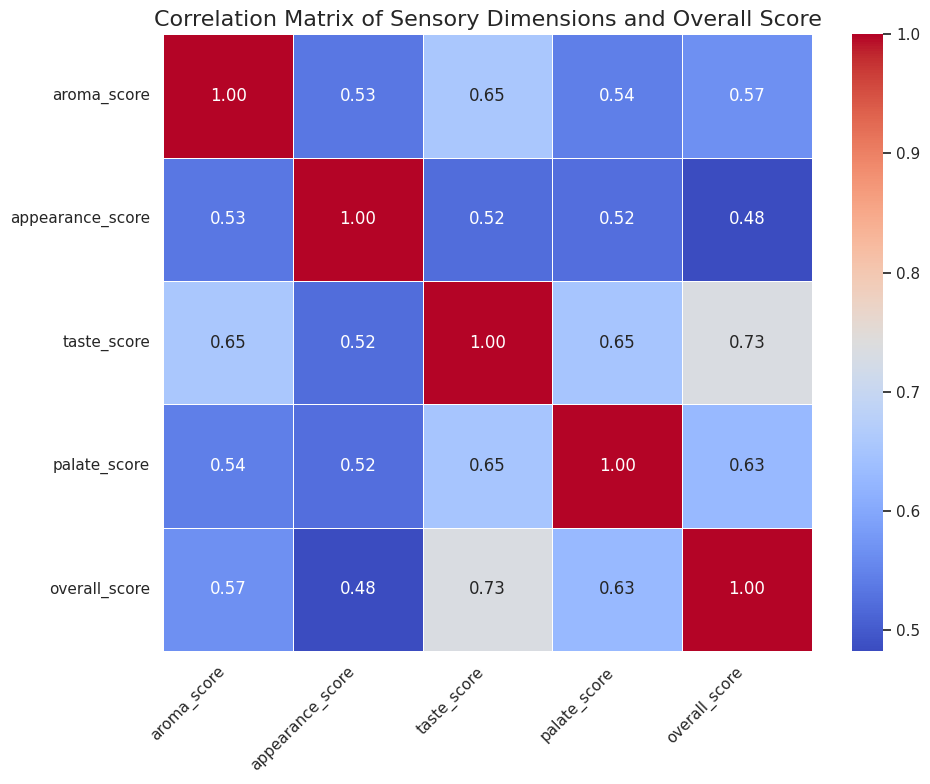

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Sensory Dimensions and Overall Score', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()



## Insights or Next Steps
*   New brewers should invest significant effort and resources into perfecting the taste profile of their beers. This includes careful selection of ingredients, precise control over the brewing process, and thorough sensory evaluation during development.
*   While 'taste' is paramount, improving 'palate_score' and 'aroma_score' will also contribute positively to the overall rating, given their moderate correlations. 'Appearance_score' has the lowest correlation, suggesting it is a less critical factor compared to the others, though still contributing to the overall experience.

## Define Brewery Size and Calculate Average Scores

### Subtask:
Define 'brewery size' by counting the number of unique beers produced by each brewery. Categorize breweries into size groups (e.g., small, medium, large) and calculate the average 'overall_score' for each brewery size category.


In [ ]:
brewery_sizes = final_merged_df.groupby('brewery_name')['beer_name'].nunique()

print("Number of unique beers per brewery (head):")
display(brewery_sizes.head())

Number of unique beers per brewery (head):


,beer_name
brewery_name,
't hofbrouwerijke,13
(512) brewing company,60
10 barrel brewing co.,23
1516 brewing company,9
16 mile brewing company,16


**Reasoning**:
To categorize breweries into size groups, I will define thresholds based on the distribution of unique beers per brewery and apply these categories using `pd.cut`.



In [ ]:
brewery_size_category = pd.cut(brewery_sizes,
                               bins=[0, 5, 50, brewery_sizes.max()],
                               labels=['Small', 'Medium', 'Large'],
                               include_lowest=True)

print("Count of breweries in each size category:")
display(brewery_size_category.value_counts())

Count of breweries in each size category:


,count
beer_name,
Small,2143
Medium,2108
Large,588


In [ ]:
final_merged_df['brewery_size_category'] = final_merged_df['brewery_name'].map(brewery_size_category)

print("final_merged_df with new 'brewery_size_category' column (head):")
display(final_merged_df.head())

final_merged_df with new 'brewery_size_category' column (head):


,review_id,aroma_score,appearance_score,taste_score,palate_score,beer_name,reviewer_username,overall_score,brewery_name,beer_style,beer_abv,brewery_size_category
0,1,2.0,2.5,1.5,1.5,sausa weizen,stcules,1.5,vecchio birraio,hefeweizen,5.0,Small
1,2,2.5,3.0,3.0,3.0,red moon,stcules,3.0,vecchio birraio,english strong ale,6.2,Small
2,4,3.0,3.5,3.0,2.5,sausa pils,stcules,3.0,vecchio birraio,german pilsener,5.0,Small
3,6,3.5,3.5,3.5,3.0,caldera ginger beer,oline73,3.0,caldera brewing company,herbed / spiced beer,4.7,Large
4,7,3.5,3.5,4.0,4.0,caldera ginger beer,Reidrover,3.5,caldera brewing company,herbed / spiced beer,4.7,Large


**Reasoning**:
Now that the 'brewery_size_category' column has been added to the DataFrame, I will group by this new column and calculate the average 'overall_score' for each category to fulfill the subtask.



In [ ]:
avg_score_by_brewery_size = final_merged_df.groupby('brewery_size_category')['overall_score'].mean()

print("Average 'overall_score' by brewery size category:")
display(avg_score_by_brewery_size)

Average 'overall_score' by brewery size category:


,overall_score
brewery_size_category,
Small,3.586265
Medium,3.721912
Large,3.857795


## Visualize Brewery Size vs. Quality

### Subtask:
Create a box plot to visualize the distribution of 'overall_score' for different brewery size categories. This will help determine if brewery size correlates with beer quality and highlight differences between small and large operations.


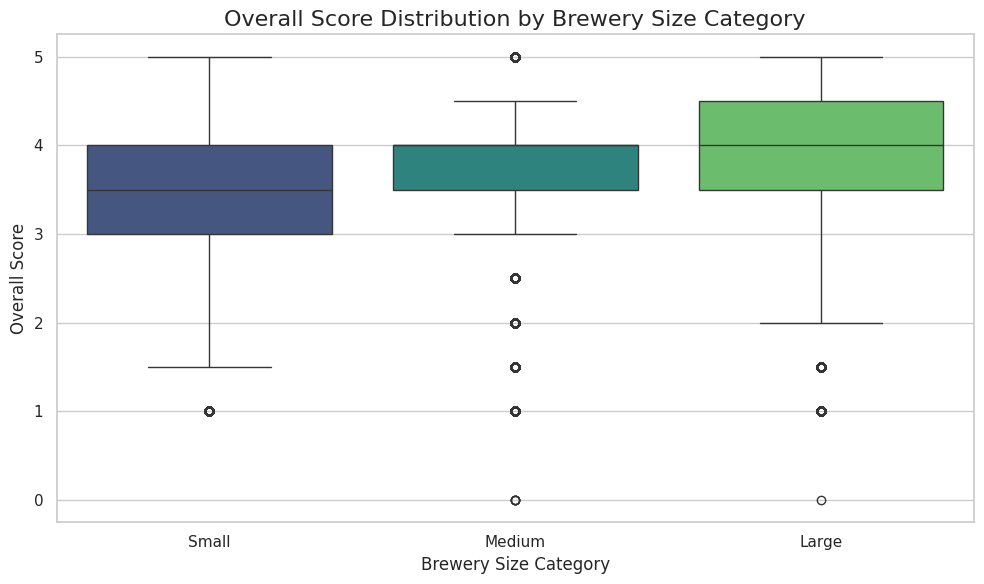

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='brewery_size_category', y='overall_score', data=final_merged_df, palette='viridis')
plt.title('Overall Score Distribution by Brewery Size Category', fontsize=16)
plt.xlabel('Brewery Size Category', fontsize=12)
plt.ylabel('Overall Score', fontsize=12)
plt.tight_layout()
plt.show()

## Brewery Size Impact on Beer Quality

### Insights or Next Steps
*   While larger breweries show a slight edge in average overall scores, the presence of variability within all categories suggests that size isn't the only determinant of quality. Further analysis could explore other factors contributing to high scores within smaller breweries.
*   For investors, the findings suggest that larger breweries might offer a safer bet for consistent, high-quality output. However, for those looking for innovation or unique offerings, smaller breweries might still be attractive, albeit with potentially higher variability in overall perception.

In [ ]:
reviewer_stats = final_merged_df.groupby('reviewer_username').agg(
    total_reviews=('review_id', 'count'),
    avg_overall_score=('overall_score', 'mean'),
    std_overall_score=('overall_score', 'std')
).reset_index()

print("Reviewer statistics (first 5 rows):")
display(reviewer_stats.head())

Reviewer statistics (first 5 rows):


,reviewer_username,total_reviews,avg_overall_score,std_overall_score
0,0110x011,260,4.228846,0.660916
1,01Ryan10,2,5.000000,0.000000
2,02maxima,2,4.500000,0.000000
3,03SVTCobra,2,4.000000,0.000000
4,04101Brewer,4,3.625000,0.250000


In [ ]:
print("\nTop 5 Reviewers by Total Reviews:")
display(reviewer_stats.sort_values(by='total_reviews', ascending=False).head(5))

print("\nTop 5 Reviewers by Average Overall Score:")
display(reviewer_stats.sort_values(by='avg_overall_score', ascending=False).head(5))

print("\nBottom 5 Reviewers by Average Overall Score:")
display(reviewer_stats.sort_values(by='avg_overall_score', ascending=True).head(5))

# Filter out reviewers with only one review as std deviation will be NaN or 0, making consistency hard to assess.
consistent_reviewers = reviewer_stats[reviewer_stats['total_reviews'] > 1]

print("\nTop 5 Most Consistent Reviewers (lowest std_overall_score, more than 1 review):")
display(consistent_reviewers.sort_values(by='std_overall_score', ascending=True).head(5))

print("\nTop 5 Least Consistent Reviewers (highest std_overall_score, more than 1 review):")
display(consistent_reviewers.sort_values(by='std_overall_score', ascending=False).head(5))


Top 5 Reviewers by Total Reviews:


,reviewer_username,total_reviews,avg_overall_score,std_overall_score
25152,northyorksammy,8418,3.684723,0.609687
2193,BuckeyeNation,7737,3.765542,0.708585
24005,mikesgroove,7669,4.095449,0.613344
14982,brentk56,5691,3.836760,0.603133
2571,ChainGangGuy,5607,3.582575,0.671228



Top 5 Reviewers by Average Overall Score:


,reviewer_username,total_reviews,avg_overall_score,std_overall_score
6569,KINGSIZE,3,5.0,0.0
6600,Kadugen,1,5.0,NaN
6622,KanataKerry,2,5.0,0.0
6661,KegMasta621,4,5.0,0.0
38,13smurrf,6,5.0,0.0



Bottom 5 Reviewers by Average Overall Score:


,reviewer_username,total_reviews,avg_overall_score,std_overall_score
4055,Emesis,5,1.0,0.0
29961,twentynine,2,1.0,0.0
27254,saltyjustice,3,1.0,0.0
11506,Thebrewer1981,1,1.0,NaN
8520,Nosferotto,2,1.0,0.0



Top 5 Most Consistent Reviewers (lowest std_overall_score, more than 1 review):


,reviewer_username,total_reviews,avg_overall_score,std_overall_score
16781,danfinlay,2,5.0,0.0
16762,danafr4,2,4.0,0.0
16767,danbristol,3,4.0,0.0
16745,dalkvist,2,4.0,0.0
16747,dalvis,2,5.0,0.0



Top 5 Least Consistent Reviewers (highest std_overall_score, more than 1 review):


,reviewer_username,total_reviews,avg_overall_score,std_overall_score
18855,fudsquat,2,3.00,2.828427
1604,BigRook,2,3.00,2.828427
26658,renekraski,2,3.00,2.828427
30654,winetrdr,2,3.25,2.474874
20474,iubball,2,2.75,2.474874


## Visualize Reviewer Traits

### Subtask:
Generate scatter plots to visualize the relationship between the number of reviews a user has submitted and their average 'overall_score', as well as between the number of reviews and the standard deviation of their scores. Also, consider bar charts for top/bottom consistent or skewed reviewers.


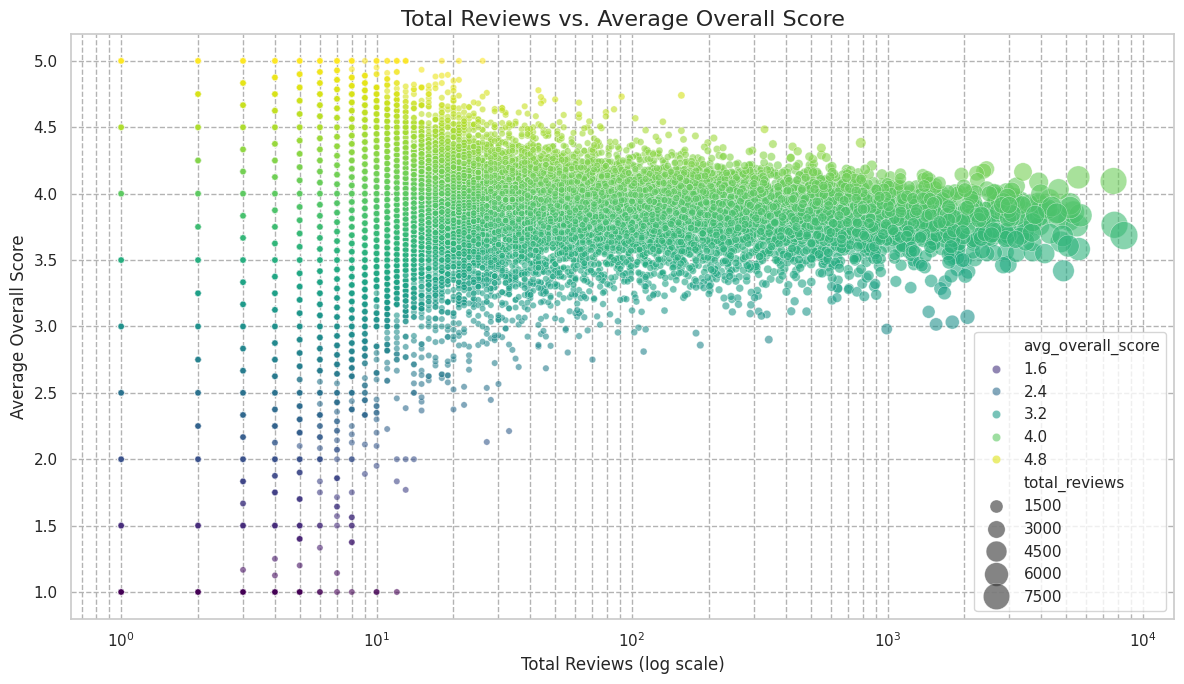

In [ ]:
plt.figure(figsize=(12, 7))
sns.scatterplot(x='total_reviews', y='avg_overall_score', data=reviewer_stats, alpha=0.6, hue='avg_overall_score', palette='viridis', size='total_reviews', sizes=(20, 400))
plt.xscale('log')
plt.title('Total Reviews vs. Average Overall Score', fontsize=16)
plt.xlabel('Total Reviews (log scale)', fontsize=12)
plt.ylabel('Average Overall Score', fontsize=12)
plt.grid(True, which='both', ls='--', c='0.7')
plt.tight_layout()
plt.show()

**Reasoning**:
I will now generate the second scatter plot to visualize the relationship between 'total_reviews' and 'std_overall_score' using the 'consistent_reviewers' DataFrame, applying a log scale to the x-axis for better visibility, and setting appropriate labels and title as per the subtask instructions.



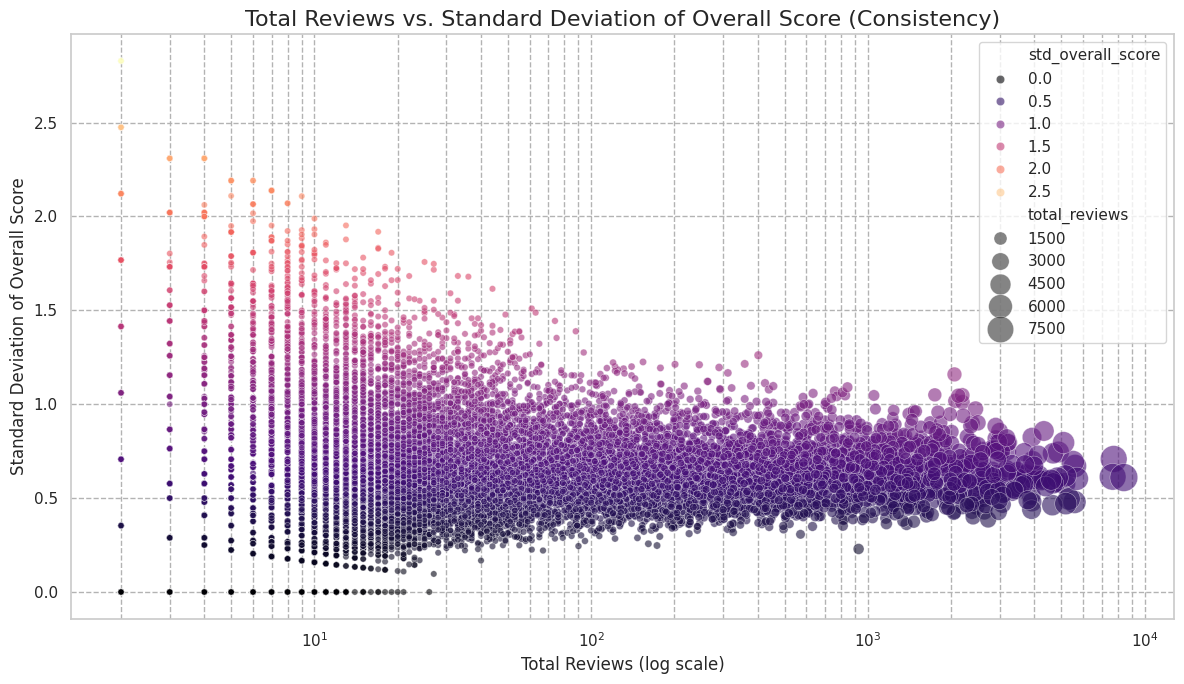

In [ ]:
plt.figure(figsize=(12, 7))
sns.scatterplot(x='total_reviews', y='std_overall_score', data=consistent_reviewers, alpha=0.6, hue='std_overall_score', palette='magma', size='total_reviews', sizes=(20, 400))
plt.xscale('log')
plt.title('Total Reviews vs. Standard Deviation of Overall Score (Consistency)', fontsize=16)
plt.xlabel('Total Reviews (log scale)', fontsize=12)
plt.ylabel('Standard Deviation of Overall Score', fontsize=12)
plt.grid(True, which='both', ls='--', c='0.7')
plt.tight_layout()
plt.show()

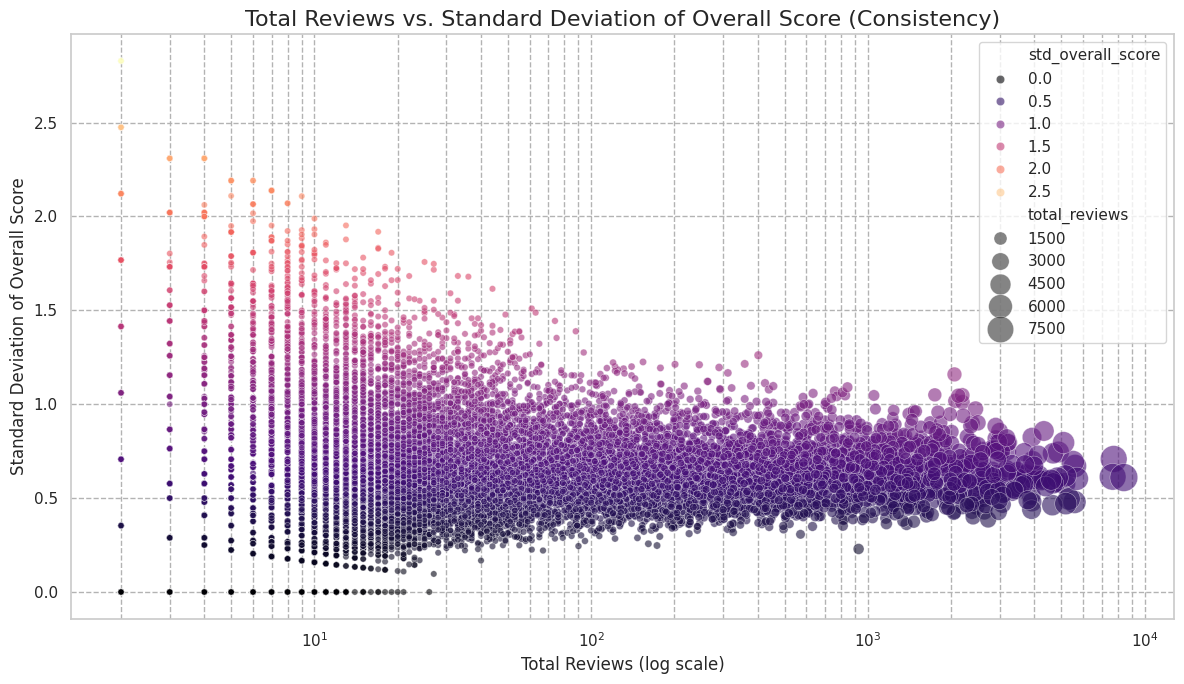

In [ ]:
plt.figure(figsize=(12, 7))
sns.scatterplot(x='total_reviews', y='std_overall_score', data=consistent_reviewers, alpha=0.6, hue='std_overall_score', palette='magma', size='total_reviews', sizes=(20, 400))
plt.xscale('log')
plt.title('Total Reviews vs. Standard Deviation of Overall Score (Consistency)', fontsize=16)
plt.xlabel('Total Reviews (log scale)', fontsize=12)
plt.ylabel('Standard Deviation of Overall Score', fontsize=12)
plt.grid(True, which='both', ls='--', c='0.7')
plt.tight_layout()
plt.show()


### Insights or Next Steps
*   For future analysis or when considering reviewer credibility, it would be beneficial to weigh reviews based on reviewer experience and consistency. Highly experienced and consistent reviewers might offer more reliable insights.
*   The observation that experienced reviewers tend to give more moderate scores suggests a maturation in their evaluation process. This could be considered when interpreting ratings, as a 4.0 from an experienced reviewer might be equivalent to a 5.0 from a novice.
*   Further investigation could involve segmenting reviewers by experience level and analyzing if their preferences for certain beer styles or breweries differ, providing deeper insights into how taste evolves with exposure.


### Insights or Next Steps
*   New brewers should prioritize developing the taste profile of their beers, as it is the most influential sensory dimension on overall ratings. While other dimensions are important, taste offers the highest return on quality investment.
*   For investors, larger breweries might represent a more reliable investment for consistent, high-quality output, given their higher average overall scores and potentially tighter quality distributions. However, smaller breweries might offer opportunities for innovation or niche markets.
*   When evaluating beer reviews, consider the reviewer's experience and consistency. Reviews from experienced and consistent individuals might offer more reliable insights into beer quality, while extreme scores from novice reviewers should be interpreted with caution.


## Prepare Data for Modeling

### Subtask:
Define what constitutes a 'top-rated beer' by creating a binary target variable (e.g., 'is_top_rated') based on the 'overall_score'. Select the sensory dimension columns as features for the model.


In [ ]:
final_merged_df['is_top_rated'] = (final_merged_df['overall_score'] >= 4.5).astype(int)

features = ['aroma_score', 'appearance_score', 'taste_score', 'palate_score']
X = final_merged_df[features]
y = final_merged_df['is_top_rated']

print("First 5 rows of X (Features):")
display(X.head())
print(f"Shape of X: {X.shape}")

print("\nFirst 5 rows of y (Target):")
display(y.head())
print(f"Shape of y: {y.shape}")

First 5 rows of X (Features):


,aroma_score,appearance_score,taste_score,palate_score
0,2.0,2.5,1.5,1.5
1,2.5,3.0,3.0,3.0
2,3.0,3.5,3.0,2.5
3,3.5,3.5,3.5,3.0
4,3.5,3.5,4.0,4.0


Shape of X: (2703279, 4)

First 5 rows of y (Target):


,is_top_rated
0,0
1,0
2,0
3,0
4,0


Shape of y: (2703279,)


## Split Data into Training and Testing Sets

### Subtask:
Divide the prepared dataset into training and testing sets to train and evaluate the predictive model.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (2162623, 4)
Shape of X_test: (540656, 4)
Shape of y_train: (2162623,)
Shape of y_test: (540656,)


## Train a Predictive Model

### Subtask:
Train a machine learning classification model (e.g., RandomForestClassifier) to predict the 'is_top_rated' target variable based on the sensory component features.


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Instantiate the classifier
model = RandomForestClassifier(random_state=42)

# Train the model
model.fit(X_train, y_train)

print("RandomForestClassifier model trained successfully.")

RandomForestClassifier model trained successfully.


## Evaluate Model Performance

### Subtask:
Evaluate the trained model's performance using appropriate metrics such as a classification report and confusion matrix to understand its accuracy and predictive power.


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

# Make predictions on the test set
y_pred = model.predict(X_test)

# Print the classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.91      0.88    403412
           1       0.66      0.51      0.58    137244

    accuracy                           0.81    540656
   macro avg       0.75      0.71      0.73    540656
weighted avg       0.80      0.81      0.80    540656



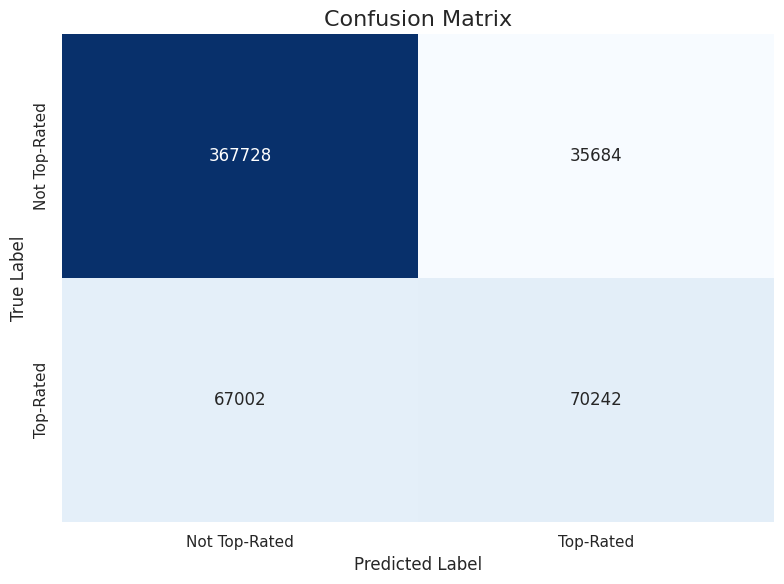

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Top-Rated', 'Top-Rated'],
            yticklabels=['Not Top-Rated', 'Top-Rated'])
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix', fontsize=16)
plt.tight_layout()
plt.show()

## Extract and Visualize Feature Importance

### Subtask:
Extract the feature importances from the trained model to identify which sensory components contribute most significantly to predicting a top-rated beer. Visualize these importances using a bar chart.


In [ ]:
feature_importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

print("Feature Importances for Predicting Top-Rated Beer:")
display(feature_importances)

Feature Importances for Predicting Top-Rated Beer:


,0
taste_score,0.568737
palate_score,0.290599
aroma_score,0.107705
appearance_score,0.032960


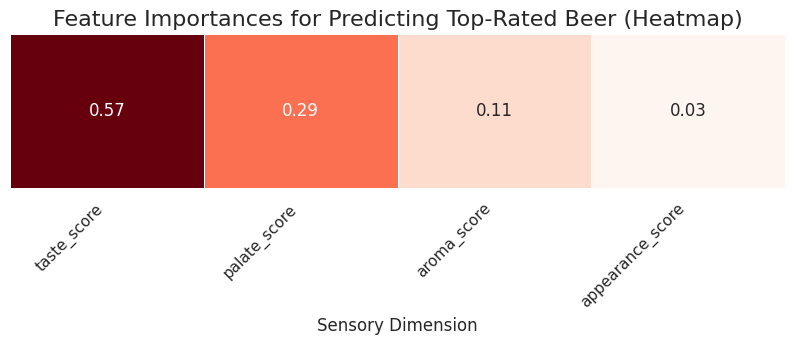

In [ ]:
plt.figure(figsize=(10, 2))
feature_importance_df = pd.DataFrame(feature_importances).T
feature_importance_df.columns = feature_importances.index

sns.heatmap(feature_importance_df, annot=True, cmap='Reds', fmt='.2f', linewidths=.5, cbar=False, yticklabels=False)
plt.title('Feature Importances for Predicting Top-Rated Beer (Heatmap)', fontsize=16)
plt.xlabel('Sensory Dimension', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### Insights or Next Steps
*   **Prioritize Taste and Palate:** Brewers seeking to produce top-rated beers should allocate the majority of their focus and resources towards refining the taste and palate characteristics, as these are the strongest drivers of consumer perception for overall quality.
*   **Refine Top-Rated Classification:** Investigate additional factors or more complex modeling techniques to better distinguish between truly top-rated beers, as the current model struggled to accurately identify all of them (recall of 0.51). This could involve exploring more granular rating data or qualitative review aspects.
